# Argus — CNN+LSTM Training (Windowed Face-Crop Sequences)

Trains the fifth model family: a `TimeDistributed(CNN) → LSTM` hybrid that sees an actual
windowed *sequence* of face-crop images, combining raw-pixel visual cues (which the
hand-engineered geometric features never captured) with genuine temporal context (which
07_cnn_training.ipynb's single-frame CNN can't see at all). See the root `CLAUDE.md`'s
"Why CNN is the most probable next backbone" for the full reasoning.

**Calibrated expectation, carried over from `09_dataset_creation_cnn_lstm.ipynb`:** this is, by
a wide margin, the most data-hungry model built so far in this project — a deep model over raw
pixel *sequences*, trained on however many subjects exist in `raw_videos/` at extraction time.
Real overfitting risk here is higher than anywhere else in this project, not lower. Worth
trying — it's the theoretically strongest architecture for this problem — but don't assume
"more complete architecture" automatically means "better result"; treat this as a real
experiment with a real chance of underperforming both 07's single-frame CNN and the geometric
LSTM, not a foregone upgrade.

**Reads:** `dataset_processed/cnn_lstm_windows_index.csv`, written by
[`09_dataset_creation_cnn_lstm.ipynb`](./09_dataset_creation_cnn_lstm.ipynb) — run that first.

**Writes:** `models/cnn_lstm_scratch_<VERSION>.keras` and
`models/cnn_lstm_mobilenet_<VERSION>.keras`.

**Two backbones, trained side by side, same shape as `07_cnn_training.ipynb`'s scratch-vs-
MobileNetV2 comparison:**
1. A **from-scratch CNN** (07's own conv-stack architecture, minus its final classification
   head) as the per-frame feature extractor.
2. A **MobileNetV2** feature extractor — but deliberately *not* 07's exact `(alpha=0.35,
   IMG_SIZE=96)` config, which collapsed there (16.81% accuracy, zero recall on one class -- a
   pre-migration 3-class run).
   `notebook/CLAUDE.md`'s "Cheaper options" section diagnoses that as more likely a
   resolution/`alpha` mismatch (a ~3×3 feature map before pooling) than a real verdict against
   pretraining, and names "a higher input resolution or larger `alpha`" as the untried fix —
   applied here (`alpha=1.0`, `IMG_SIZE_MOBILENET=128`) to give it a real shot rather than
   reproducing the same collapse inside a more expensive model.

Both share the same `LSTM(64) → Dropout → Dense(2, softmax)` head, the same subject-grouped
split, the same focal-loss/class-weight setup, and the same val-macro-F1-based checkpointing —
so any accuracy difference between them is attributable to the backbone, not to a different
training setup, mirroring 07's own framing.

**Update:** this run also fuses in a small set of hand-engineered geometric features
(`EAR_left/right`, `MAR`, and the top-ranked eye/brow blendshapes) alongside the CNN embedding at
every timestep -- see "Building the `tf.data` Pipeline" and "Model Definition" below -- plus a
lower initial learning rate (`1e-4`, down from `1e-3` -- tightened again from an intermediate `3e-4` pass after that run showed clear overfitting) and an optional class-weight scheme
(a `Drowsy` boost on top of `'balanced'`, gated behind `USE_CLASS_WEIGHTS` and off for the last
run) described in "CNN+LSTM Training (From-Scratch Backbone)" below.


## Google Drive Connection & Project Setup


In [1]:
from google.colab import drive
import os
import datetime
import pandas as pd

drive.mount('/content/drive')

# --- Argus project paths (must match 09_dataset_creation_cnn_lstm.ipynb) ---
project_folder = "/content/drive/MyDrive/Argus"
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
cnn_lstm_windows_csv_path = os.path.join(processed_folder, "cnn_lstm_windows_index.csv")

if not os.path.exists(cnn_lstm_windows_csv_path):
    raise FileNotFoundError(
        f"'{cnn_lstm_windows_csv_path}' not found. Run 09_dataset_creation_cnn_lstm.ipynb "
        "first -- this notebook only trains against the window index it produces, it doesn't "
        "build it."
    )

df_cnn_lstm_windows = pd.read_csv(cnn_lstm_windows_csv_path)
if 'geometric_feature_seq' not in df_cnn_lstm_windows.columns:
    raise ValueError(
        "cnn_lstm_windows_index.csv has no 'geometric_feature_seq' column -- re-run "
        "09_dataset_creation_cnn_lstm.ipynb (it now also extracts per-frame EAR/MAR/"
        "blendshape features for fusion; a CSV from before that update won't have this "
        "column)."
    )
print(f"Loaded window index: {len(df_cnn_lstm_windows)} windows, "
      f"{df_cnn_lstm_windows['subject'].nunique()} subjects.")

# --- Model Management Configuration ---
FORCE_RETRAIN = True
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
cnn_lstm_scratch_model_path = os.path.join(models_folder, f"cnn_lstm_scratch_{VERSION_STR}.keras")
cnn_lstm_mobilenet_model_path = os.path.join(models_folder, f"cnn_lstm_mobilenet_{VERSION_STR}.keras")

def get_latest_model(folder, prefix, extension):
    """Return the path of the most recently versioned model matching prefix/extension, or None."""
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}. Force retrain: {FORCE_RETRAIN}")


Mounted at /content/drive
Loaded window index: 5763 windows, 54 subjects.
✅ Model management initialized. Current version: 20260827_2245. Force retrain: True


## Splitting the Dataset

Group-aware split by subject, same rationale and same rule as `07_cnn_training.ipynb`'s
now-migrated `split_by_subject_fold` — ported here and called on the window index instead of the
crop index (same `subject`/`level` columns, same meaning). Binary task (`Not Drowsy` / `Drowsy`):
only subjects with **both** classes represented among their windows are eligible to be a held-out
*test* or *validation* subject; genuinely single-class subjects (e.g. a failed clip extraction)
still contribute real training windows for whichever class they have, they just can't be a
held-out fold. The split happens on the **index CSV** (window metadata + `;`-joined path lists),
before any image is decoded — pixel loading happens lazily in the `tf.data` pipeline below, same
as 07.

**Validation is now a real KFold fold, not the incomplete-subject pool.** The 3-class version of
this notebook derived `val` from the pool of class-incomplete subjects, and always put every such
subject into validation without ever rotating them. Under binary labels almost every UTA-RLDD
subject has both classes (each recorded an alert clip and a drowsy clip), so that pool is usually
empty — `val` is now fold `(fold_idx + 1) % n_splits` of the same `StratifiedGroupKFold`, a
distinct, disjoint subject group from the test fold. It's still small (one KFold fold's worth of
subjects) and still a plausible independent source of the epoch-to-epoch `val_macro_f1` noise
seen in training logs. `split_by_subject_fold` stays parameterized by `fold_idx`/`n_splits`
specifically so a future subject-fold cross-validation diagnostic (mirroring
`07_cnn_training.ipynb`'s `RUN_CROSS_VALIDATION` cells) could measure how much that noise
actually moves the reported number.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
import numpy as np


def split_by_subject_fold(df, fold_idx=0, n_splits=None, random_state=42):
    """Subject-grouped train/val/test split for the window index, parameterized by fold index so
    the same logic can drive both the main fold-0 split below and a future subject-fold
    cross-validation diagnostic, without duplicating the split rules. Ported from
    07_cnn_training.ipynb's now-migrated version -- called on the window index instead of the
    crop index (same `subject`/`level` columns, same meaning).

    Binary task (Not Drowsy / Drowsy). A subject is "complete" if it has windows for BOTH classes
    {1, 2}; only complete subjects can be held out as *test* or *validation* subjects, since a
    single-class held-out fold can't score both classes. Incomplete subjects (only one class
    present -- e.g. a failed clip extraction) are NOT dropped: they stay in the training pool as
    valid windows for whichever class they have.

        test  = fold `fold_idx` of a StratifiedGroupKFold over the complete subjects
        val   = fold `(fold_idx + 1) % n_splits` -- a different, disjoint subject group
        train = every other complete subject + all incomplete subjects

    The 3-class version of this notebook derived `val` from the pool of class-incomplete subjects
    instead. Under binary labels almost every UTA-RLDD subject has both classes (each recorded an
    alert clip and a drowsy clip), so that pool is usually empty -- hence val is now a KFold fold
    like test.

    Returns (df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits_used).
    """
    subject_level_sets = df.groupby('subject')['level'].agg(set)
    complete_subjects = subject_level_sets[subject_level_sets == {1, 2}].index
    incomplete_subjects = subject_level_sets.index.difference(complete_subjects)

    if len(complete_subjects) < 3:
        raise ValueError(
            f"Only {len(complete_subjects)} subject(s) have both classes ({list(complete_subjects)}) "
            "-- need at least 3 to hold one out for testing and one for validation. Finish dataset "
            "extraction (06_dataset_creation_face_crops.ipynb + 09_dataset_creation_cnn_lstm.ipynb) "
            "for more subjects before training."
        )

    df_complete = df[df['subject'].isin(complete_subjects)]
    n_splits = n_splits or min(5, len(complete_subjects))
    if not (0 <= fold_idx < n_splits):
        raise ValueError(f"fold_idx={fold_idx} out of range for n_splits={n_splits}")

    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_subjects = [
        set(df_complete.iloc[test_pos]['subject'])
        for _, test_pos in sgkf.split(df_complete, df_complete['level'], groups=df_complete['subject'])
    ]

    test_subjects = fold_subjects[fold_idx]
    val_subjects = fold_subjects[(fold_idx + 1) % n_splits]

    test_mask = df['subject'].isin(test_subjects)
    val_mask = df['subject'].isin(val_subjects)
    train_mask = ~test_mask & ~val_mask

    df_train = df[train_mask].reset_index(drop=True)
    df_val = df[val_mask].reset_index(drop=True)
    df_test = df[test_mask].reset_index(drop=True)

    all_levels = set(df['level'].unique())
    for name, part in (('Validation', df_val), ('Test', df_test)):
        missing = all_levels - set(part['level'].unique())
        if missing:
            raise ValueError(f"{name} fold missing level(s) {sorted(missing)} -- treat as a bug.")

    return df_train, df_val, df_test, complete_subjects, incomplete_subjects, n_splits


df_train, df_val, df_test, complete_subjects, incomplete_subjects, N_SPLITS = split_by_subject_fold(
    df_cnn_lstm_windows, fold_idx=0
)
print(f"Complete-class subjects ({len(complete_subjects)}): {list(complete_subjects)}")
print(f"Incomplete subjects ({len(incomplete_subjects)}): {list(incomplete_subjects)}")
print(f"Train: {len(df_train)} windows, Val: {len(df_val)} windows, Test: {len(df_test)} windows")
print(f"Test-fold windows by duration:\n{df_test['window_duration_sec'].value_counts().sort_index()}")

## Building the `tf.data` Pipeline

Each row's `image_paths` (`;`-joined) has exactly `n_real_frames` real images (3/5/10/20 — no
partial windows, see `09`). Per window:

1. Split the path list, decode + resize each real frame.
2. Zero-**pre**-pad to `MAX_TIMESTEPS_IMG=20` (zeros first, real frames last) — matching this
   project's established rolling-buffer convention (root `CLAUDE.md`: padding has to match how a
   live buffer actually fills, oldest-dropped/newest-appended).
3. Build a boolean mask of shape `(MAX_TIMESTEPS_IMG,)` **directly from the already-known
   `n_real_frames` value**, not by inferring it from all-zero pixels. A plain Keras `Masking`
   layer only reduces over the *last* axis of its input — that's exactly right for the geometric
   LSTM's all-zero 58-float timestep, but wrong for an all-zero `(H, W, 3)` image timestep here.
   Computing the mask from the known real length sidesteps that entirely, and is strictly more
   correct anyway: a genuinely all-black *real* frame would never be misdetected as padding this
   way, unlike with a value-based `Masking` layer.
4. Feed the mask directly into the `LSTM` layer's `call()` (`LSTM(...)(x, mask=mask_input)`) —
   the officially-supported way to pass an explicit mask to a Keras RNN layer — rather than a
   preceding `Masking` layer.

**Window-level augmentation, not per-frame.** Every frame in a window is the same continuous
stretch of one clip, so flip/rotation/zoom/contrast/brightness must be sampled **once per
window** and applied identically to every real frame in it — flipping frame 3 but not frame 7 of
the same window would be incoherent. Calling `tf.keras.layers.Random*` directly on a
`(T, H, W, C)` tensor would sample independently per leading-axis entry (its normal batch
behavior), reproducing exactly that wrong per-frame-independent behavior — so rotation/zoom/
contrast are applied via a fold-time-into-channels trick instead (`(T,H,W,3) → (1,H,W,T*3)`,
augment once, unfold), and flip/brightness via one manually-sampled decision applied to the whole
window at once.

**Per-frame Gaussian noise is the one exception — applied independently per real frame,
deliberately.** Real camera sensor noise genuinely varies frame to frame in actual video, unlike
flip/rotation/zoom (properties of the whole camera framing), so sampling it independently per
frame is the *realistic* choice here, not a bug to avoid.

**`BATCH_SIZE=8` / `BATCH_SIZE_MOBILENET=4`, both down from 07's 32.** Each padded scratch-CNN
example is `20×96×96×3` floats — roughly 20x heavier than one of 07's single images — and the
MobileNetV2 variant's larger `128×128` frames make its examples heavier still, so both batch
sizes are reduced accordingly rather than left at 07's value.


**Update: a parallel geometric feature sequence.** Each row's `geometric_feature_seq`
(`;`-per-frame, `,`-per-feature, written by `09_dataset_creation_cnn_lstm.ipynb`) is parsed and
zero-*pre*-padded the same way as `image_paths`, producing a `(MAX_TIMESTEPS_IMG,
NUM_GEO_FEATURES)` tensor that lines up 1:1 against the same `mask` used for the image sequence.
This does **not** go through the image augmentation pipeline -- see "Model Definition" below for
where it's normalized and fused with the CNN embedding.


In [ ]:
import tensorflow as tf
import numpy as np

MAX_TIMESTEPS_IMG = 20                 # Must match 09_dataset_creation_cnn_lstm.ipynb's own
                                        # MAX_TIMESTEPS_IMG (max_context_sec * sampling_fps = 20*1).
IMG_SIZE = 96                          # From-scratch CNN input resolution -- same as 07 (same
                                        # underlying crops, no reason to change it here).
IMG_SIZE_MOBILENET = 128               # Deliberately larger than 96 -- see the Model section
                                        # below for why (07's alpha=0.35/96x96 collapse).
BATCH_SIZE = 8                         # Down from 07's 32 -- see markdown above.
BATCH_SIZE_MOBILENET = 4               # Smaller still: larger resolution + a heavier backbone.
CLASS_NAMES = ['Not Drowsy', 'Drowsy']
NOISE_STDDEV = 0.03                    # Std-dev of additive Gaussian noise on a [0,255]-scaled
                                        # image (applied as NOISE_STDDEV * 255) -- a conservative
                                        # starting point; sanity-check visually before trusting it
                                        # (see "Augmented Sample Preview" below), same bar 07's own
                                        # augmentation choices were held to.

# Must match 09_dataset_creation_cnn_lstm.ipynb's GEO_FEATURE_NAMES exactly, same order -- these
# just name what each column of a parsed geometric_feature_seq frame actually is.
GEO_FEATURE_NAMES = [
    'EAR_left', 'EAR_right', 'MAR',
    'eyeWideRight', 'eyeBlinkRight', 'browOuterUpRight',
    'eyeBlinkLeft', 'eyeSquintLeft', 'eyeWideLeft', 'eyeSquintRight',
]
NUM_GEO_FEATURES = len(GEO_FEATURE_NAMES)


def _decode_and_resize(path, img_size):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [img_size, img_size])
    return image  # float32, [0, 255] range -- Rescaling(1/255) happens inside the model, as in 07


def _parse_geo_seq(geo_seq_str, num_geo_features):
    """'v1,...,v10;v1,...,v10;...' (one ';'-joined group of NUM_GEO_FEATURES comma-joined floats
    per real frame, written by 09_dataset_creation_cnn_lstm.ipynb) -> (n_real_frames,
    num_geo_features) float32 tensor.
    """
    frames = tf.strings.split(geo_seq_str, ';')
    per_frame = tf.strings.split(frames, ',').to_tensor(default_value='0.0', shape=[None, num_geo_features])
    return tf.strings.to_number(per_frame, out_type=tf.float32)


def load_window(image_paths_str, geo_seq_str, n_real_frames, label, img_size, max_timesteps,
                 num_geo_features):
    """One window row -> (padded_images, padded_geo, mask, label).

    `n_real_frames` is the exact, already-known count of real frames (not inferred). Padding is
    zero-*pre*-padded (zeros first, real frames last) to match this project's rolling-buffer
    convention -- applied identically to the image sequence and the geometric feature sequence,
    so both line up against the same `mask`.
    """
    paths = tf.strings.split(image_paths_str, ';')
    real_images = tf.map_fn(
        lambda p: _decode_and_resize(p, img_size), paths, fn_output_signature=tf.float32,
    )  # (n_real_frames, img_size, img_size, 3)
    real_geo = _parse_geo_seq(geo_seq_str, num_geo_features)  # (n_real_frames, num_geo_features)

    pad_amount = max_timesteps - n_real_frames
    padded_images = tf.pad(real_images, [[pad_amount, 0], [0, 0], [0, 0], [0, 0]])
    padded_images.set_shape([max_timesteps, img_size, img_size, 3])
    padded_geo = tf.pad(real_geo, [[pad_amount, 0], [0, 0]])
    padded_geo.set_shape([max_timesteps, num_geo_features])

    mask = tf.range(max_timesteps) >= pad_amount  # True for the last n_real_frames positions

    return padded_images, padded_geo, mask, label


# Same rotation/zoom/contrast augmenter as 07's geometric_augmenter, reused via the fold/unfold
# trick below so ONE random draw covers the whole window instead of one draw per frame.
geometric_augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),   # ~+/-18 degrees, same as 07
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2),
])


def _apply_shared_geometric_augmentation(images, img_size):
    """Applies `geometric_augmenter` with ONE shared random draw across every frame in the
    window. Keras preprocessing layers sample an independent transform per element of whatever
    leading axis they're given -- calling them directly on images shaped (T, H, W, 3) would
    reproduce 07's independent-per-image behavior, wrong for a sequence. Folding time into the
    channel axis first -- (T, H, W, 3) -> (1, H, W, T*3) -- makes the layer see one single image
    with many channels instead of T separate images, so it draws one transform for the whole
    thing; unfolding afterward restores the per-frame tensor.
    """
    t = tf.shape(images)[0]
    folded = tf.reshape(tf.transpose(images, [1, 2, 0, 3]), [1, img_size, img_size, -1])
    folded = geometric_augmenter(folded, training=True)
    unfolded = tf.reshape(folded, [img_size, img_size, t, 3])
    return tf.transpose(unfolded, [2, 0, 1, 3])


def augment_window(images, geo, mask, label, img_size):
    """Augmentation shared across every real frame in the window (flip/brightness/rotation/zoom/
    contrast), plus independent per-frame Gaussian noise -- see the markdown above for why noise
    is the one exception applied per-frame rather than per-window. `geo` (the geometric feature
    sequence) deliberately passes through untouched -- these image-space transforms have no
    corresponding effect to apply to an already-computed EAR/MAR/blendshape ratio, unlike
    07/09's crop pipeline, which augments before feature extraction ever happens.
    """
    # --- Flip: one shared coin flip for the whole window ---
    do_flip = tf.random.uniform([]) < 0.5
    images = tf.cond(do_flip, lambda: tf.image.flip_left_right(images), lambda: images)

    # --- Brightness: one shared delta, added identically to every frame ---
    brightness_delta = tf.random.uniform([], -0.15, 0.15) * 255.0
    images = tf.clip_by_value(images + brightness_delta, 0.0, 255.0)

    # --- Rotation/zoom/contrast: one shared draw via the fold-into-channels trick ---
    images = _apply_shared_geometric_augmentation(images, img_size)

    # --- Per-frame Gaussian noise: independent per real timestep, deliberately ---
    noise = tf.random.normal(tf.shape(images), stddev=NOISE_STDDEV * 255.0)
    images = tf.clip_by_value(images + noise, 0.0, 255.0)

    return images, geo, mask, label


def make_dataset(df, training: bool, img_size: int, batch_size: int):
    image_paths = df['image_paths'].to_numpy()
    geo_seqs = df['geometric_feature_seq'].to_numpy()
    n_real_frames = df['n_real_frames'].to_numpy(dtype=np.int32)
    labels = (df['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Not Drowsy, 1=Drowsy

    ds = tf.data.Dataset.from_tensor_slices((image_paths, geo_seqs, n_real_frames, labels))
    ds = ds.map(
        lambda p, g, n, l: load_window(p, g, n, l, img_size, MAX_TIMESTEPS_IMG, NUM_GEO_FEATURES),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
        ds = ds.map(lambda img, g, m, l: augment_window(img, g, m, l, img_size),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda img, g, m, l: ((img, g, m), l), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# --- From-scratch CNN datasets (IMG_SIZE=96) ---
train_ds = make_dataset(df_train, training=True, img_size=IMG_SIZE, batch_size=BATCH_SIZE)
val_ds = make_dataset(df_val, training=False, img_size=IMG_SIZE, batch_size=BATCH_SIZE)
test_ds = make_dataset(df_test, training=False, img_size=IMG_SIZE, batch_size=BATCH_SIZE)

# --- MobileNetV2 datasets (IMG_SIZE_MOBILENET=128) -- a separate pipeline, not a resize of the
# above, since the two backbones deliberately use different input resolutions (see Model below).
train_ds_mobilenet = make_dataset(df_train, training=True, img_size=IMG_SIZE_MOBILENET,
                                   batch_size=BATCH_SIZE_MOBILENET)
val_ds_mobilenet = make_dataset(df_val, training=False, img_size=IMG_SIZE_MOBILENET,
                                 batch_size=BATCH_SIZE_MOBILENET)
test_ds_mobilenet = make_dataset(df_test, training=False, img_size=IMG_SIZE_MOBILENET,
                                  batch_size=BATCH_SIZE_MOBILENET)

print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE} | "
      f"IMG_SIZE_MOBILENET={IMG_SIZE_MOBILENET}, BATCH_SIZE_MOBILENET={BATCH_SIZE_MOBILENET} | "
      f"NUM_GEO_FEATURES={NUM_GEO_FEATURES}")


### Augmented Sample Preview

A cheap, direct sanity check before trusting the pipeline blind: pull one augmented training
window and confirm (a) the geometric augmentation (flip/rotation/zoom/contrast) looks identical
across every real frame, (b) the per-frame noise is visibly present but not so strong it obscures
the eye/mouth region, and (c) the mask's real-frame count matches `n_real_frames`, and the real
frames are the *last* positions (pre-padding), not the first.


Label: Drowsy, mask real-frame count: 5 (real frames occupy the LAST 5 of 20 positions -- pre-padding)
First real frame's geometric features (['EAR_left', 'EAR_right', 'MAR', 'eyeWideRight', 'eyeBlinkRight', 'browOuterUpRight', 'eyeBlinkLeft', 'eyeSquintLeft', 'eyeWideLeft', 'eyeSquintRight']):
[0.3115 0.3144 0.0039 0.011  0.0511 0.261  0.0648 0.2693 0.0092 0.157 ]


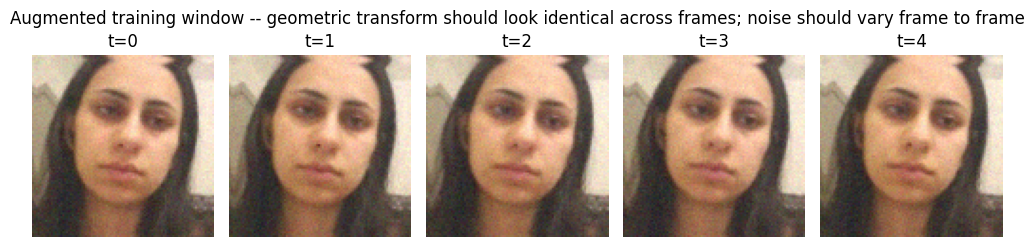

In [4]:
import matplotlib.pyplot as plt

for (sample_images, sample_geo, sample_mask), sample_label in train_ds.take(1):
    break

sample_idx = 0
images_np = sample_images[sample_idx].numpy()
geo_np = sample_geo[sample_idx].numpy()
mask_np = sample_mask[sample_idx].numpy()
n_real = int(mask_np.sum())

print(f"Label: {CLASS_NAMES[int(sample_label[sample_idx].numpy())]}, "
      f"mask real-frame count: {n_real} (real frames occupy the LAST {n_real} of "
      f"{MAX_TIMESTEPS_IMG} positions -- pre-padding)")
assert (mask_np[-n_real:]).all() and not (mask_np[:MAX_TIMESTEPS_IMG - n_real]).any(), \
    "Mask shape doesn't match the expected pre-padding layout -- check load_window's padding order."

# The geometric feature sequence should be zero for every padded (non-real) position and
# non-trivial for every real one -- a direct check that its padding lines up with the image mask.
geo_real = geo_np[-n_real:]
geo_padded = geo_np[:MAX_TIMESTEPS_IMG - n_real]
assert not geo_padded.any(), "Padded geometric feature positions should be all-zero."
print(f"First real frame's geometric features ({GEO_FEATURE_NAMES}):\n{geo_real[0].round(4)}")

real_frames = images_np[MAX_TIMESTEPS_IMG - n_real:]
n_preview = min(8, len(real_frames))
preview_idx = np.linspace(0, len(real_frames) - 1, n_preview, dtype=int)
fig, axes = plt.subplots(1, n_preview, figsize=(2 * n_preview, 2.5))
for ax, idx in zip(np.atleast_1d(axes), preview_idx):
    ax.imshow(np.clip(real_frames[idx] / 255.0, 0, 1))
    ax.set_title(f"t={idx}")
    ax.axis('off')
plt.suptitle("Augmented training window -- geometric transform should look identical across "
             "frames; noise should vary frame to frame")
plt.tight_layout()
plt.show()


## Loss Function

`SparseCategoricalFocalLoss`, ported unchanged from `07_cnn_training.ipynb` (same reasoning:
`Drowsy` is plausibly the rarest, most safety-critical class, and focal loss down-weights
easy/already-confident examples so training focuses on the harder, more ambiguous ones).


In [5]:
from tensorflow.keras.losses import SparseCategoricalCrossentropy, CategoricalCrossentropy
import tensorflow as tf
import keras

num_classes = len(CLASS_NAMES)  # CLASS_NAMES defined earlier in "Building the tf.data Pipeline"

USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
LABEL_SMOOTHING = 0.05

@keras.saving.register_keras_serializable(package="CustomLosses")
class SparseCategoricalFocalLoss(keras.losses.Loss):
    def __init__(self, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING,
                 reduction='sum_over_batch_size', name='sparse_categorical_focal_loss'):
        super().__init__(reduction=reduction, name=name)
        self.gamma = gamma
        self.label_smoothing = label_smoothing
        self.cce_per_example = CategoricalCrossentropy(from_logits=False, reduction=None)

    def call(self, y_true, y_pred):
        y_true_int = tf.cast(y_true, tf.int32)
        num_classes_tensor = tf.shape(y_pred)[1]
        y_true_one_hot = tf.one_hot(y_true_int, depth=num_classes_tensor)

        if self.label_smoothing > 0.0:
            num_classes_float = tf.cast(num_classes_tensor, tf.float32)
            y_true_one_hot = y_true_one_hot * (1.0 - self.label_smoothing) + (self.label_smoothing / num_classes_float)

        ce = self.cce_per_example(y_true_one_hot, y_pred)
        probs_true_class = tf.reduce_sum(y_pred * y_true_one_hot, axis=-1)
        probs_true_class = tf.clip_by_value(probs_true_class, 1e-7, 1.0 - 1e-7)

        modulating_factor = tf.pow(1.0 - probs_true_class, self.gamma)
        return modulating_factor * ce

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'label_smoothing': self.label_smoothing})
        return config


def build_loss():
    if USE_FOCAL_LOSS:
        return SparseCategoricalFocalLoss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTHING)
    return SparseCategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING)


## Model Definition — `TimeDistributed(CNN) → LSTM`

Two per-frame feature extractors, sharing the same recurrent head:

- **From-scratch:** 07's `build_cnn_scratch` conv stack (`Conv2D→BatchNorm→MaxPool` ×3), stopped
  at its `GlobalAveragePooling2D → Dense(64, relu)` embedding — its final `Dense(2, softmax)`
  head is dropped, since classification happens after the LSTM here, not per-frame. **No
  per-layer `l2()` regularization here anymore** — see the "Regularization update" note below.
- **MobileNetV2:** frozen `imagenet` weights, `alpha=1.0` and `IMG_SIZE_MOBILENET=128` — a real
  fix attempt for 07's pre-migration 3-class collapse (16.81% accuracy, zero recall on one
  class), not a repeat of its exact `(alpha=0.35, IMG_SIZE=96)` config. `notebook/CLAUDE.md`'s "Cheaper options" section
  diagnoses that collapse as more likely a resolution/`alpha` mismatch (`alpha=0.35` at 96×96
  downsamples to roughly a 3×3 feature map before pooling, discarding most spatial detail in the
  eye/mouth region) than a real verdict against pretraining.

Both are wrapped in `TimeDistributed`, feeding a **single 64-unit `LSTM`** — not the geometric
LSTM's two-layer 128→64 stack. The `TimeDistributed(CNN)` already contributes far more trainable
parameters per timestep (a real conv stack, or MobileNetV2) than the geometric LSTM's 58
hand-engineered floats — this is already the most overfitting-prone model in the project (see the
notebook-level "Calibrated expectation" note above), so the recurrent head is kept smaller here
specifically to offset that, not copied at the same size by default.

The mask is passed explicitly into the `LSTM`'s call (`LSTM(...)(x, mask=mask_input)`) rather
than via a preceding `Masking` layer — see "Building the `tf.data` Pipeline" above for why. The
`TimeDistributed` CNN does still run (wastefully) on zero-padded frames; its output for those
timesteps just doesn't affect the LSTM's hidden-state trajectory, since masked timesteps are
skipped there. Accepted cost of the padding+mask approach.

**Update: geometric feature fusion.** Per timestep, the `TimeDistributed(CNN)` embedding is
concatenated with a normalized 10-feature EAR/MAR/blendshape vector (`GEO_FEATURE_NAMES` above,
extracted per-frame by `09_dataset_creation_cnn_lstm.ipynb` -- see its "Geometric Features for
Fusion" section) before the fused sequence goes into the `LSTM`. Normalization uses a
`tf.keras.layers.Normalization` layer (`geo_normalizer`) adapted once on `df_train`'s real
(non-padded) frames and reused unchanged for both backbones, the same precedent as the class
weights below. `learning_rate` dropped from `0.001` to `1e-4` in an earlier pass (an intermediate
`3e-4` pass showed clear overfitting -- steadily climbing train accuracy against a flat/noisy,
trending-worse `val_macro_f1`); `ReduceLROnPlateau`'s `patience` dropped from `8` to `4` at the
same time, for the same reason.

**Update: regularization, not learning rate, is this round's lever.** Two full training runs at
different learning rates (`3e-4`, then `1e-4` decaying to ~1.25e-5 via `ReduceLROnPlateau`) both
converged to the *same* early `val_macro_f1` peak (epoch ~3-5, ~0.40-0.46) followed by the same
decline shape. Three very different LR magnitudes hitting the same ceiling means the learning
rate isn't the lever holding it down -- so `learning_rate` stays at `1e-4` here, deliberately
**not** lowered further (pushing it lower risks settling into a sharper, more overfit minimum
rather than fixing the ceiling -- LR mainly governs how fast training gets somewhere, not how
well that somewhere generalizes). Two changes that actually target capacity/regularization
instead:
1. **`AdamW`'s decoupled weight decay** (`WEIGHT_DECAY = 1e-4`) replaces plain `Adam` + `l2()`
   scattered across every conv/dense layer — L2-inside-Adam interacts poorly with Adam's
   per-parameter adaptive rates and is a weaker, more erratic form of the same regularization
   AdamW does more cleanly. The `l2()` kernel regularizers above are removed, not kept alongside
   AdamW, to avoid double-regularizing the same weights.
2. **`recurrent_dropout=0.3`** on the `LSTM`, on top of its existing `dropout=0.3` — the LSTM
   previously had zero regularization on its recurrent (hidden-state-to-hidden-state)
   connections, only on its input. This would normally cost the cuDNN fast path, but
   `use_cudnn=False` is already forced here for the pre-padding reason above, so it's free.


**Update: `CosineDecayRestarts` (SGDR) replaces `ReduceLROnPlateau` for the from-scratch model.**
The most recent run added one more, direct piece of evidence against a monotonically-shrinking
LR: as `ReduceLROnPlateau` cut `1e-4` down to `6.25e-6` over that run, `val_macro_f1` at that
lowest LR (~0.22-0.23) was worse than at every higher LR earlier in the *same* run -- not just a
cross-run pattern anymore. `CosineDecayRestarts` takes the same underlying idea one step further:
instead of only ever shrinking the LR, it decays smoothly within each cycle and then jumps the LR
back **up** at each restart, deliberately re-perturbing the model out of whatever region it
settled into rather than letting it settle further. Configured with a ~5-epoch first cycle
(matching where `val_macro_f1` has peaked in every run so far), `t_mul=2.0` (cycles double in
length), `m_mul=0.9` (each restart's peak LR cools slightly), and `alpha=0.05` (each cycle's
trough floors at 5% of that cycle's peak, not near-zero). `ReduceLROnPlateau` is removed for this
model rather than combined with the schedule -- the two don't compose (`ReduceLROnPlateau`
expects a plain scalar `optimizer.lr`, not a `LearningRateSchedule`) and would otherwise fight
each other.


In [6]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, Rescaling, Conv2D, BatchNormalization, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Dropout, TimeDistributed, LSTM, Concatenate, Normalization,
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
import math

EMBED_DIM = 64  # Per-frame embedding size out of either backbone, before the LSTM.

# --- Regularization update: AdamW's decoupled weight decay, not Adam + l2(). ---
# Previously every conv/dense layer below carried kernel_regularizer=l2(0.001) on top of plain
# Adam. Inside Adam, an L2 penalty gets folded into the gradient before Adam's per-parameter
# adaptive moment estimates are computed, which interacts poorly with those adaptive rates and
# can produce less effective, more erratic regularization than true decoupled weight decay (see
# Loshchilov & Hutter's AdamW paper, and https://www.fast.ai/posts/2018-07-02-adam-weight-decay.html).
# Switching to AdamW's `weight_decay` argument gets a cleaner, better-supported version of the
# same regularization -- so the l2() kernel_regularizer args below are REMOVED, not kept
# alongside AdamW: stacking both double-regularizes the same weights and reintroduces the exact
# interaction problem AdamW is meant to fix.
WEIGHT_DECAY = 1e-4


def build_scratch_feature_extractor(img_size):
    """Per-frame CNN feature extractor -- 07's build_cnn_scratch conv stack, stopped at its
    GlobalAveragePooling2D -> Dense(64) embedding (its final Dense(3, softmax) head is dropped:
    classification happens after the LSTM here, not per-frame). No per-layer l2() here anymore --
    see the "Regularization update" note above; AdamW's weight_decay (passed at compile time in
    build_cnn_lstm below) covers this instead.
    """
    return Sequential([
        Input(shape=(img_size, img_size, 3)),
        Rescaling(1. / 255),
        Conv2D(16, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(32, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),
        Conv2D(64, 3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(),
        GlobalAveragePooling2D(),
        Dense(EMBED_DIM, activation='relu'),
    ], name='scratch_feature_extractor')


def build_mobilenet_feature_extractor(img_size, alpha=1.0, trainable_backbone=False):
    """Per-frame MobileNetV2 feature extractor. Deliberately alpha=1.0 (not 07's 0.35) and a
    larger img_size (see the Model markdown cell above) -- a real attempt at fixing 07's
    resolution/alpha-diagnosed collapse, not a repeat of the exact config that collapsed there.
    No l2() on the embedding Dense here either -- see the "Regularization update" note above.
    """
    base = MobileNetV2(input_shape=(img_size, img_size, 3), alpha=alpha, include_top=False,
                        weights='imagenet')
    base.trainable = trainable_backbone
    inputs = Input(shape=(img_size, img_size, 3))
    x = preprocess_input(inputs)
    x = base(x, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(EMBED_DIM, activation='relu')(x)
    model = Model(inputs, x, name='mobilenet_feature_extractor')
    return model, base


# --- Geometric feature normalizer, adapted once on the real (non-padded) training frames -- see
# the "Geometric feature fusion" note in the Model markdown cell above. Reused unchanged for both
# backbones below, same precedent as the class weights: only the backbone differs between the two
# training runs, not how the geometric side of the input is normalized. ---
_geo_train_real_frames = np.array([
    [float(v) for v in frame.split(',')]
    for seq in df_train['geometric_feature_seq']
    for frame in seq.split(';')
], dtype=np.float32)
geo_normalizer = Normalization(axis=-1, name='geo_normalizer')
geo_normalizer.adapt(_geo_train_real_frames)
print(f"Geo feature normalizer adapted on {_geo_train_real_frames.shape[0]} real frames "
      f"({NUM_GEO_FEATURES} features).")


# --- Recurrent regularization: recurrent_dropout on top of the existing input dropout=0.3. ---
# The LSTM below previously had zero regularization on its recurrent connections -- dropout=0.3
# only randomly zeroes the LSTM's *input* at each timestep, not its hidden-state-to-hidden-state
# connections, which is where an RNN's own overfitting capacity mostly lives. Normally
# recurrent_dropout>0 disables Keras' cuDNN fast path, a real cost -- but use_cudnn=False is
# already forced below for an unrelated reason (pre-padded, not right-padded, sequences), so this
# model gets standard RNN regularization for free rather than trading anything away for it.
RECURRENT_DROPOUT = 0.3


def build_cnn_lstm(feature_extractor, img_size, max_timesteps=MAX_TIMESTEPS_IMG,
                    num_geo_features=NUM_GEO_FEATURES, num_classes=num_classes,
                    learning_rate=1e-4, name='cnn_lstm'):
    """Wraps a per-frame feature extractor in TimeDistributed, concatenates its output sequence
    with the normalized per-frame geometric feature sequence (EAR/MAR/blendshapes), feeds the
    fused sequence into a single LSTM(64) with an explicit mask, then a small classification
    head. See the Model markdown cell above for why a single, modestly-sized LSTM layer rather
    than the geometric LSTM's two-layer stack.

    `learning_rate` defaults to a plain 1e-4 float here, but the from-scratch call below passes a
    `CosineDecayRestarts` schedule object instead (Keras optimizers accept either) -- see the
    schedule definition below for why. Four full training runs now (learning_rate=3e-4, then 1e-4
    decaying via ReduceLROnPlateau down to ~1.25e-5, then again down to 6.25e-6) all converged to
    the SAME early val_macro_f1 peak (epoch ~3-5, ~0.40-0.46) followed by the same decline shape,
    and within the most recent run val_macro_f1 at the lowest LR (6.25e-6) was directly worse than
    at every higher LR earlier in that same run -- a monotonically-shrinking LR was never the
    lever that raises this ceiling, and now has direct within-run evidence of making things worse.
    AdamW's weight_decay (this function's compile step) and recurrent_dropout (below) target that
    ceiling more directly; the schedule below is a further, different experiment on top.
    """
    image_input = Input(shape=(max_timesteps, img_size, img_size, 3), name='images')
    geo_input = Input(shape=(max_timesteps, num_geo_features), name='geo_features')
    mask_input = Input(shape=(max_timesteps,), dtype=tf.bool, name='mask')

    cnn_embeddings = TimeDistributed(feature_extractor)(image_input)  # (T, EMBED_DIM)
    normalized_geo = geo_normalizer(geo_input)                        # (T, num_geo_features)
    fused = Concatenate(axis=-1)([cnn_embeddings, normalized_geo])    # (T, EMBED_DIM + num_geo_features)

    # Fix: Set use_cudnn=False because sequences are pre-padded, not right-padded
    x = LSTM(64, dropout=0.3, recurrent_dropout=RECURRENT_DROPOUT, use_cudnn=False)(fused, mask=mask_input)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model([image_input, geo_input, mask_input], outputs, name=name)
    model.compile(optimizer=AdamW(learning_rate=learning_rate, weight_decay=WEIGHT_DECAY),
                  loss=build_loss(), metrics=['accuracy'])
    return model


# --- Learning rate schedule: CosineDecayRestarts (SGDR) instead of a flat LR handed to
# ReduceLROnPlateau. Every run so far shows the same shape -- val_macro_f1 peaks early (epoch
# ~3-5) then declines as training continues -- and ReduceLROnPlateau's own monotonic decay has
# now directly made that decline WORSE, not better (see the docstring above and
# notebook/CLAUDE.md's "What we found"). CosineDecayRestarts implements the same underlying idea
# behind that observation -- let the LR go back UP periodically to knock training out of whatever
# region it settled into, rather than only ever shrinking it -- in its established, well-tested
# form, rather than a custom callback reacting to val_macro_f1 directly. Deliberately NOT
# metric-reactive: val_macro_f1 comes from only 234 validation windows (6 subjects) and is noisy
# enough that a scheme reacting to it in real time risks mistaking noise for "stuck".
STEPS_PER_EPOCH_SCRATCH = math.ceil(len(df_train) / BATCH_SIZE)
lr_schedule_scratch = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=STEPS_PER_EPOCH_SCRATCH * 5,  # ~5 epochs per first cycle -- matches where
                                                      # val_macro_f1 peaked in every run so far.
    t_mul=2.0,   # each subsequent cycle is 2x longer than the last (~5 -> 10 -> 20 epochs, ...).
    m_mul=0.9,   # each restart's peak LR is 90% of the previous cycle's -- a mild cooldown across
                 # restarts, not a full reset to 1e-4 every time.
    alpha=0.05,  # floors each cycle's trough at 5% of that cycle's peak, not near-zero -- avoids
                 # the "very low LR made things worse" failure mode already measured directly.
)

model_scratch = build_cnn_lstm(build_scratch_feature_extractor(IMG_SIZE), img_size=IMG_SIZE,
                                learning_rate=lr_schedule_scratch, name='cnn_lstm_scratch')
model_scratch.summary()


Geo feature normalizer adapted on 26058 real frames (10 features).


Model: "cnn_lstm_scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer) │ (None, 20, 96,    │          0 │ -                 │
│                     │ 96, 3)            │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ geo_features        │ (None, 20, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 64)    │     28,192 │ images[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ geo_normalizer      │ (None, 20, 10)    │         21 │ geo_features[0][… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 20, 74)    │          0 │ time_distributed… │
│ (Concatenate)       │                   │            │ geo_normalizer[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     35,584 │ concatenate[0][0… │
│                     │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 63,992 (249.97 KB)

 Trainable params: 63,747 (249.01 KB)

 Non-trainable params: 245 (984.00 B)

## CNN+LSTM Training (From-Scratch Backbone)

`class_weight`, computed from the training set's actual **window-level** label distribution
(pooling all 4 durations together -- same precedent as `03_model_training_lstm.ipynb` pooling its
own multi-duration window mix into one training set). **Update: disabled for this run
(`USE_CLASS_WEIGHTS = False`).** Earlier passes applied class weighting on top of `'balanced'`
(with a `Drowsy` boost; a 3-class version also dampened the ambiguous middle class, which no
longer exists) and all showed the same early-peak-then-decline `val_macro_f1` pattern regardless
of learning rate -- since that pattern persisted across very different learning rates, the
learning rate was ruled out as the cause (see the Model Definition markdown above); the
class-weight skew combined with a small `BATCH_SIZE=8` is the next candidate (individual batches
dominated by one heavily-weighted example, plausibly driving epoch-to-epoch `val_macro_f1`
noise). This run isolates that by training with `class_weight=None` -- a genuinely uniform,
unweighted loss, not just the `Drowsy` boost turned off on top of `'balanced'`. **Real tradeoff, not hidden:** `Drowsy` is the single most
safety-critical class in this project -- watch its recall in the eval cells below; if it craters
here, that's a real cost of this experiment to weigh against any accuracy/macro-F1 gain. **Worth
noting either way: the late-run decline never actually reached the saved model** -- `ModelCheckpoint`
below keeps only the best `val_macro_f1` epoch (`save_best_only=True`), so it's wasted training
time, not a corrupted result. `MacroF1Callback` and the val-macro-F1-based `EarlyStopping`/
`ModelCheckpoint` setup are ported from 07 -- see that notebook for why raw `val_accuracy` isn't
a safe selection metric under class imbalance. **`ReduceLROnPlateau` is no longer part of this
model's callbacks** -- `learning_rate` is now a `CosineDecayRestarts` schedule handed directly to
`AdamW` (see the Model Definition markdown above), which handles decay/restarts on its own and
doesn't compose with a plateau-based callback.


In [ ]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os


class MacroF1Callback(Callback):
    """Adds `val_macro_f1` to the epoch's `logs` dict so EarlyStopping/ModelCheckpoint below can
    select on it instead of raw accuracy -- ported from 07, works unmodified against this
    notebook's ((images, mask), label) dataset shape: only the top-level (inputs, label)
    structure matters for `for _, y in self.val_ds` and `self.model.predict(self.val_ds)`.
    """
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        y_true = np.concatenate([y.numpy() for _, y in self.val_ds])
        y_pred = np.argmax(self.model.predict(self.val_ds, verbose=0), axis=1)
        logs['val_macro_f1'] = f1_score(y_true, y_pred, average='macro',
                                         labels=list(range(num_classes)), zero_division=0)


# --- Class-weight toggle: OFF for this run. ---
# An earlier (3-class) version of this notebook applied class_weight unconditionally -- an
# asymmetric scheme on top of sklearn's 'balanced' weights. Every such pass still showed the same
# early-peak-then-decline val_macro_f1 pattern regardless of learning rate (see build_cnn_lstm's
# docstring above). This run tests a different candidate cause instead: with a small
# BATCH_SIZE=8, individual batches can be dominated by one heavily reweighted example, which is a
# plausible contributor to how noisy val_macro_f1 is epoch to epoch (TensorFlow's own
# imbalanced-data guidance notes this small-batch-plus-reweighting interaction). USE_CLASS_WEIGHTS
# isolates that: when False, class_weight=None below means a genuinely uniform, unweighted loss
# -- not just turning off the Drowsy boost on top of 'balanced', which would still weight classes
# unevenly by frequency.
#
# Real tradeoff, not hidden: Drowsy is the single most safety-critical class in this project. If
# turning weighting off tanks Drowsy recall in the eval cells below, that's a genuine cost of this
# experiment to weigh against any accuracy/macro-F1 gain, not evidence the experiment failed.
USE_CLASS_WEIGHTS = False

# Drowsy (binary label 1 = old level 3) is still the safety-critical minority -- the state it's
# least acceptable to miss -- so if weighting is re-enabled it keeps a boost on top of 'balanced'.
# The 3-class scheme also dampened the ambiguous middle class; that half is gone with the class.
DROWSY_LABEL = CLASS_NAMES.index('Drowsy')  # 1
DROWSY_WEIGHT_BOOST = 1.5          # Only applied if USE_CLASS_WEIGHTS -- tuned down from 2.0 (briefly 3.0).

if USE_CLASS_WEIGHTS:
    train_labels = (df_train['level'].to_numpy(dtype=np.int32) - 1)
    weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
    weight_dict = dict(zip(np.unique(train_labels).tolist(), weights))
    weight_dict[DROWSY_LABEL] *= DROWSY_WEIGHT_BOOST
    print(f"Class weights (Drowsy boosted {DROWSY_WEIGHT_BOOST}x): {weight_dict}")
else:
    weight_dict = None  # None -> Keras trains with a plain, unweighted loss (no per-class penalty at all).
    print("USE_CLASS_WEIGHTS=False -- training with class_weight=None (uniform), testing whether "
          "reweighting itself was contributing to noisy val_macro_f1 rather than fixing it.")

macro_f1_cb = MacroF1Callback(val_ds)
early_stopping = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15,
                                restore_best_weights=True)
checkpoint_scratch = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_lstm_scratch.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)
# No ReduceLROnPlateau here anymore -- the from-scratch model's learning_rate is now a
# CosineDecayRestarts schedule (see cell above), which already handles LR decay/restarts on its
# own schedule. Combining a LearningRateSchedule object with ReduceLROnPlateau doesn't compose
# cleanly (ReduceLROnPlateau expects to read/write a plain scalar optimizer.lr) and would fight
# the schedule's own restarts, so it's removed rather than kept alongside it.

print("🚀 Training CNN+LSTM (from-scratch backbone)...")
history_scratch = model_scratch.fit(
    train_ds,
    epochs=100,
    validation_data=val_ds,
    callbacks=[macro_f1_cb, early_stopping, checkpoint_scratch],
    class_weight=weight_dict,
    verbose=1,
)


## Evaluation (From-Scratch Backbone)

Same shape as 07: `classification_report`/confusion matrix/macro-F1 on the held-out test
subjects, loaded from the best `val_macro_f1` checkpoint. Also reports accuracy **broken down by
`window_duration_sec`** — something 07 has no equivalent of, since it has no duration dimension —
which directly answers whether more temporal context actually helps, the whole premise of
building this model. `test_ds` is never shuffled, so `y_pred`'s order lines up 1:1 with
`df_test`'s row order.


Loading best CNN+LSTM (from-scratch) checkpoint from /content/drive/MyDrive/Argus/models/best_cnn_lstm_scratch.keras...
147/147 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step

CNN+LSTM (from-scratch) Test Loss: 0.5174
CNN+LSTM (from-scratch) Test Accuracy: 0.3521
CNN+LSTM (from-scratch) Test Macro-F1: 0.3464

Classification Report (CNN+LSTM (from-scratch)):
              precision    recall  f1-score   support

       Alert       0.39      0.46      0.42       390
Low Vigilant       0.20      0.17      0.19       390
      Drowsy       0.44      0.42      0.43       390

    accuracy                           0.35      1170
   macro avg       0.34      0.35      0.35      1170
weighted avg       0.34      0.35      0.35      1170



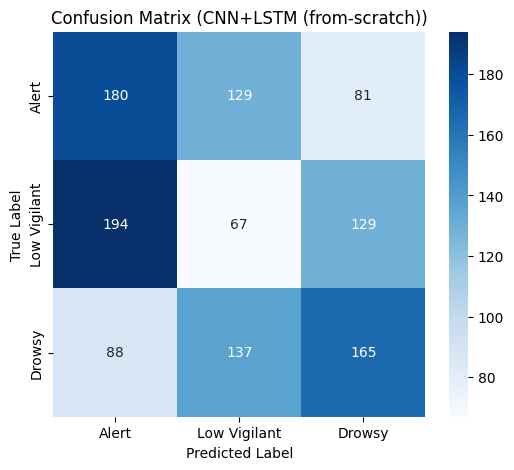


Accuracy by window duration (CNN+LSTM (from-scratch)):
                     accuracy  n_windows
window_duration_sec                     
3.0                  0.355556        540
5.0                  0.352778        360
10.0                 0.338889        180
20.0                 0.355556         90


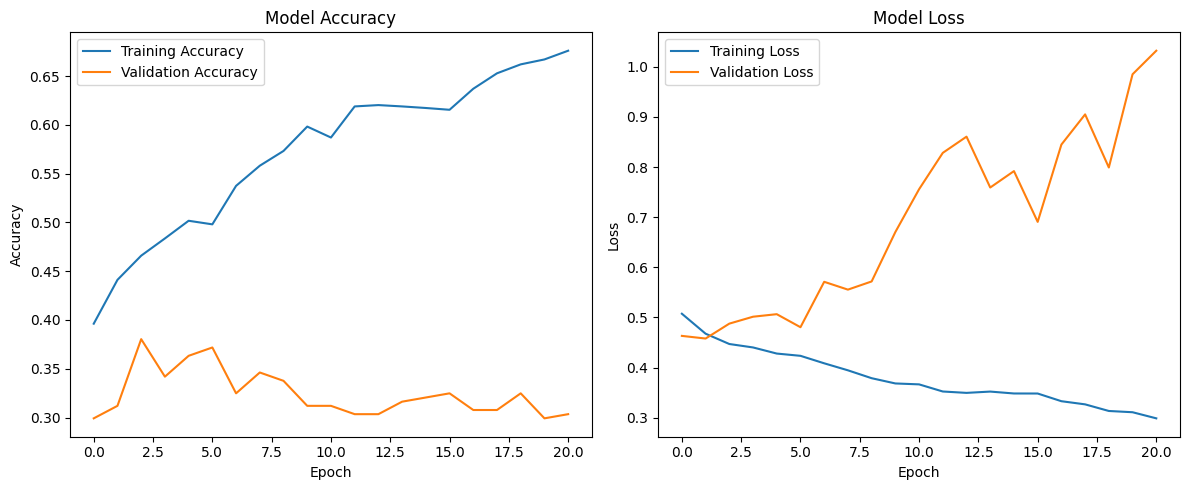

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.optimizers import Adam

def evaluate_variant(model_path, fallback_model, test_dataset, test_df, variant_label):
    """Loads the best checkpoint (falling back to the in-memory model if the checkpoint file
    isn't found), evaluates against test_dataset, prints a classification report + confusion
    matrix, and returns (y_true, y_pred, per_duration_accuracy) for later comparison.
    """
    custom_objects = {'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss}
    if os.path.exists(model_path):
        print(f"Loading best {variant_label} checkpoint from {model_path}...")
        # Note: compile=False avoids certain loading errors; we re-compile or just use for inference.
        model_eval = tf.keras.models.load_model(model_path, custom_objects=custom_objects, compile=False)

        # Fix for cuDNN error: Ensure LSTM layers use_cudnn=False for pre-padded sequences
        for layer in model_eval.layers:
            if isinstance(layer, tf.keras.layers.LSTM):
                layer.use_cudnn = False

        # RE-COMPILE: Necessary because we loaded with compile=False
        model_eval.compile(optimizer=Adam(learning_rate=1e-4), loss=build_loss(), metrics=['accuracy'])
    else:
        print(f"Best {variant_label} checkpoint not found, falling back to in-memory model.")
        model_eval = fallback_model

    loss, accuracy = model_eval.evaluate(test_dataset, verbose=0)
    y_true = np.concatenate([y.numpy() for _, y in test_dataset])
    y_pred = np.argmax(model_eval.predict(test_dataset), axis=1)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"\n{variant_label} Test Loss: {loss:.4f}")
    print(f"{variant_label} Test Accuracy: {accuracy:.4f}")
    print(f"{variant_label} Test Macro-F1: {macro_f1:.4f}")
    print(f"\nClassification Report ({variant_label}):")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix ({variant_label})')
    plt.show()

    # --- Per-duration accuracy breakdown -- the question this whole model exists to answer ---
    eval_df = test_df.reset_index(drop=True).copy()
    eval_df['correct'] = (y_true == y_pred)
    per_duration = eval_df.groupby('window_duration_sec')['correct'].agg(['mean', 'count'])
    per_duration.columns = ['accuracy', 'n_windows']
    print(f"\nAccuracy by window duration ({variant_label}):")
    print(per_duration)

    return y_true, y_pred, per_duration


y_true_scratch, y_pred_scratch, per_duration_scratch = evaluate_variant(
    os.path.join(models_folder, 'best_cnn_lstm_scratch.keras'),
    model_scratch, test_ds, df_test, 'CNN+LSTM (from-scratch)',
)

if 'history_scratch' in globals():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_scratch.history['accuracy'], label='Training Accuracy')
    plt.plot(history_scratch.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_scratch.history['loss'], label='Training Loss')
    plt.plot(history_scratch.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.show()

## Frozen-CNN-Embedding + LSTM Variant (Cheaper Alternative)

Added alongside the from-scratch and MobileNetV2 variants above, not replacing either -- see
`notebook/CLAUDE.md`'s "Cheaper options considered alongside the full CNN+LSTM build" (option 3)
and "What we found": the from-scratch CNN+LSTM's pre-migration 3-class test result (32.22% accuracy,
0.3251 macro-F1 -- at the 33.3% random-guess chance for that balanced 3-class test set) was a
real train/test generalization-gap problem that survived every regularization change tried on it
(`AdamW` weight decay, LSTM dropout/recurrent dropout, focal loss, class-weight toggling,
`CosineDecayRestarts`). No binary run has happened yet -- but that consistency points at model
capacity relative to subject count, not an undiscovered hyperparameter, and collapsing to two
classes raises the random-guess floor to 50% rather than closing that gap -- so this section
tries a genuinely lower-capacity model instead of tuning the same one further.

Instead of training a CNN backbone end-to-end inside the recurrent graph
(`TimeDistributed(CNN) -> LSTM`, what the from-scratch/MobileNetV2 variants above both do), this
reuses `07_cnn_training.ipynb`'s already-trained single-frame CNN as a **frozen** per-frame
feature extractor: its 64-dim penultimate-layer embedding (`GlobalAveragePooling2D -> Dense(64)`,
before its classification head) is computed once per crop and concatenated with the same 10-dim
`geometric_feature_seq` (EAR/MAR/blendshapes) already used above, then only a small `LSTM(64)` +
classification head is trained on top of that fused, precomputed sequence. Far fewer trainable
parameters than the from-scratch variant -- no CNN weights are updated at all here -- which is
the whole point: a model with less capacity to memorize 48 subjects' worth of training windows by
identity rather than by drowsiness cues.

**Real tradeoff, stated up front:** because the CNN side is frozen and its embeddings are
precomputed once rather than recomputed per batch, this variant does **not** get the image-space
augmentation (flip/brightness/rotation/zoom/contrast/noise) the from-scratch pipeline applies
every epoch -- augmenting would mean re-running the CNN per augmented copy, which defeats the
"cheap" premise here. If this variant still overfits, that's the first thing to add back (e.g.
caching a handful of augmented embedding copies per crop), not a sign the frozen-embedding
approach itself doesn't work.

In [14]:
import tensorflow as tf
import numpy as np
import os

# --- Load 07's already-trained single-frame CNN as a frozen feature extractor ---
cnn_scratch_checkpoint_path = os.path.join(models_folder, 'best_cnn_scratch_face_crops.keras')
if not os.path.exists(cnn_scratch_checkpoint_path):
    raise FileNotFoundError(
        f"'{cnn_scratch_checkpoint_path}' not found. Run 07_cnn_training.ipynb first -- this "
        "variant reuses its trained CNN as a frozen feature extractor rather than training a new "
        "one from scratch."
    )

_cnn_07 = tf.keras.models.load_model(
    cnn_scratch_checkpoint_path,
    custom_objects={'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss},
    compile=False,
)
_cnn_07.trainable = False  # Frozen backbone

# Force initialization by calling the model with dummy data.
_ = _cnn_07(tf.zeros((1, IMG_SIZE, IMG_SIZE, 3)))

# The 64-dim embedding is 07's penultimate layer: GlobalAveragePooling2D -> Dense(64, relu)
_dense_layers = [l for l in _cnn_07.layers if isinstance(l, tf.keras.layers.Dense)]
if len(_dense_layers) < 2:
    raise ValueError(
        f"Expected at least 2 Dense layers in the loaded CNN, found {len(_dense_layers)}."
    )
_embedding_layer = _dense_layers[-2]
EMBED_DIM_FROZEN = _embedding_layer.output.shape[-1]

# FIX: Instead of _cnn_07.input, we use the input of the first layer (InputLayer)
# to avoid the 'never been called' error when building a sub-model from a loaded file.
model_input = _cnn_07.layers[0].input

frozen_cnn_embedder = tf.keras.Model(
    inputs=model_input,
    outputs=_embedding_layer.output,
    name='frozen_cnn_embedder',
)
print(f"Loaded frozen CNN embedder from {cnn_scratch_checkpoint_path} "
      f"(embedding layer: '{_embedding_layer.name}', EMBED_DIM_FROZEN={EMBED_DIM_FROZEN}).")

Loaded frozen CNN embedder from /content/drive/MyDrive/Argus/models/best_cnn_scratch_face_crops.keras (embedding layer: 'dense', EMBED_DIM_FROZEN=64).


In [15]:
# --- Precompute a frozen embedding for every unique crop image referenced by any window ---
# Crops are shared across many (often overlapping/tiled) windows of different durations -- 09's
# window builder tiles non-overlapping windows per duration config from the same underlying
# frames -- so embedding each *unique* image once and caching it is both correct and much
# cheaper than recomputing per window. Uses ALL windows in df_cnn_lstm_windows (not just
# df_train), since df_val/df_test crops need cached embeddings too.
_all_image_paths = pd.unique(df_cnn_lstm_windows['image_paths'].str.split(';').explode())
print(f"Precomputing frozen CNN embeddings for {len(_all_image_paths)} unique crop images...")

def _load_for_embedding(path):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_jpeg(image_bytes, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])  # Same IMG_SIZE=96 as 07 -- same crops.
    return image

_embed_ds = tf.data.Dataset.from_tensor_slices(_all_image_paths)
_embed_ds = _embed_ds.map(_load_for_embedding, num_parallel_calls=tf.data.AUTOTUNE)
_embed_ds = _embed_ds.batch(128).prefetch(tf.data.AUTOTUNE)

_embeddings = frozen_cnn_embedder.predict(_embed_ds, verbose=1)
embedding_by_path = dict(zip(_all_image_paths, _embeddings))
print(f"✅ Cached {len(embedding_by_path)} embeddings, shape per crop: {_embeddings.shape[1:]}")

Precomputing frozen CNN embeddings for 8903 unique crop images...
70/70 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step
✅ Cached 8903 embeddings, shape per crop: (64,)


In [ ]:
def build_fused_arrays(df, embedding_by_path, max_timesteps, embed_dim, num_geo_features):
    """Turns each window row into a padded (max_timesteps, embed_dim + num_geo_features) fused
    feature array plus a boolean mask, entirely in numpy -- no tf.data image pipeline needed here
    since the CNN side is a cached lookup rather than a per-batch forward pass. Same zero-
    pre-pad convention as load_window above (zeros first, real frames last), so results stay
    directly comparable to the from-scratch variant.
    """
    n = len(df)
    fused_dim = embed_dim + num_geo_features
    X = np.zeros((n, max_timesteps, fused_dim), dtype=np.float32)
    mask = np.zeros((n, max_timesteps), dtype=bool)
    y = (df['level'].to_numpy(dtype=np.int32) - 1)  # 0-indexed: 0=Not Drowsy, 1=Drowsy

    for i, row in enumerate(df.itertuples(index=False)):
        paths = row.image_paths.split(';')
        n_real = len(paths)
        embeds = np.stack([embedding_by_path[p] for p in paths])            # (n_real, embed_dim)
        geo_frames = [
            [float(v) for v in frame.split(',')] for frame in row.geometric_feature_seq.split(';')
        ]
        geo = np.array(geo_frames, dtype=np.float32)                        # (n_real, num_geo_features)
        fused = np.concatenate([embeds, geo], axis=-1)                      # (n_real, fused_dim)

        pad_amount = max_timesteps - n_real
        X[i, pad_amount:] = fused
        mask[i, pad_amount:] = True

    return X, mask, y


X_train_fe, mask_train_fe, y_train_fe = build_fused_arrays(
    df_train, embedding_by_path, MAX_TIMESTEPS_IMG, EMBED_DIM_FROZEN, NUM_GEO_FEATURES)
X_val_fe, mask_val_fe, y_val_fe = build_fused_arrays(
    df_val, embedding_by_path, MAX_TIMESTEPS_IMG, EMBED_DIM_FROZEN, NUM_GEO_FEATURES)
X_test_fe, mask_test_fe, y_test_fe = build_fused_arrays(
    df_test, embedding_by_path, MAX_TIMESTEPS_IMG, EMBED_DIM_FROZEN, NUM_GEO_FEATURES)

print(f"Fused feature shapes -- train: {X_train_fe.shape}, val: {X_val_fe.shape}, "
      f"test: {X_test_fe.shape}")

### Model Definition (Frozen CNN Embedding + LSTM)

Reuses the same `LSTM(64)` + `Dropout(0.5)` + classification-head shape as `build_cnn_lstm`
above, but with a single fused-feature `Input` instead of separate images/geo/mask inputs feeding
a `TimeDistributed(CNN)` -- there's no CNN left inside this graph to wrap, since it already ran
once during the precompute step above. A `Normalization` layer, adapted on the real (non-padded)
training frames, standardizes the fused vector before the LSTM -- the same role `geo_normalizer`
plays above, just covering the CNN-embedding columns too now rather than only the geometric
ones.

In [17]:
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense, Normalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import AdamW

FUSED_DIM_FROZEN = EMBED_DIM_FROZEN + NUM_GEO_FEATURES

fused_normalizer_frozen = Normalization(axis=-1, name='fused_normalizer_frozen')
fused_normalizer_frozen.adapt(X_train_fe[mask_train_fe])
print(f"Fused feature normalizer adapted on {mask_train_fe.sum()} real training frames "
      f"({FUSED_DIM_FROZEN} features: {EMBED_DIM_FROZEN} CNN embedding + {NUM_GEO_FEATURES} "
      "geometric).")


def build_frozen_embedding_lstm(max_timesteps=MAX_TIMESTEPS_IMG, fused_dim=FUSED_DIM_FROZEN,
                                 num_classes=num_classes, learning_rate=1e-4,
                                 name='cnn_lstm_frozen_embedding'):
    """Deliberately much smaller than build_cnn_lstm above: with the CNN frozen and precomputed,
    there's no TimeDistributed(CNN) in this graph at all -- only an LSTM(64) + small head train,
    on top of already-fused (embedding + geometric) per-timestep vectors. Far fewer trainable
    parameters than the end-to-end from-scratch CNN+LSTM, by design -- see the markdown cell
    above for why a lower-capacity model is the point of this variant, not an oversight.
    """
    fused_input = Input(shape=(max_timesteps, fused_dim), name='fused_features')
    mask_input = Input(shape=(max_timesteps,), dtype=tf.bool, name='mask')

    x = fused_normalizer_frozen(fused_input)
    x = LSTM(64, dropout=0.3, recurrent_dropout=0.3, use_cudnn=False)(x, mask=mask_input)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model([fused_input, mask_input], outputs, name=name)
    model.compile(optimizer=AdamW(learning_rate=learning_rate, weight_decay=WEIGHT_DECAY),
                  loss=build_loss(), metrics=['accuracy'])
    return model


model_frozen_embedding = build_frozen_embedding_lstm()
model_frozen_embedding.summary()

Fused feature normalizer adapted on 26058 real training frames (74 features: 64 CNN embedding + 10 geometric).


Model: "cnn_lstm_frozen_embedding"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fused_features      │ (None, 20, 74)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fused_normalizer_f… │ (None, 20, 74)    │        149 │ fused_features[0… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     35,584 │ fused_normalizer… │
│                     │                   │            │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3)         │        195 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,928 (140.35 KB)

 Trainable params: 35,779 (139.76 KB)

 Non-trainable params: 149 (600.00 B)

### Training (Frozen CNN Embedding + LSTM)

Reuses `MacroF1Callback`, the `val_macro_f1`-monitored `EarlyStopping`/`ModelCheckpoint`
pattern, and whatever `USE_CLASS_WEIGHTS` resolved `weight_dict` to above, for the same
comparability reasons the MobileNetV2 variant reused the from-scratch split's class weights.
One real difference worth flagging: `BATCH_SIZE_FROZEN` is much larger than the from-scratch
variant's `BATCH_SIZE=8`, since no images flow through this pipeline per batch -- only small
fused vectors -- so the small-batch-plus-reweighting interaction `USE_CLASS_WEIGHTS=False` was
testing for the from-scratch model doesn't necessarily carry over here. Worth revisiting
`USE_CLASS_WEIGHTS` independently for this variant if `Drowsy` recall comes back weak, rather
than assuming the same setting is automatically right for both.

In [18]:
def make_fused_dataset(X, mask, y, batch_size, training):
    ds = tf.data.Dataset.from_tensor_slices(((X, mask), y))
    if training:
        ds = ds.shuffle(buffer_size=2048, seed=42)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


BATCH_SIZE_FROZEN = 32  # Much larger than the from-scratch variant's BATCH_SIZE=8 -- memory
                         # isn't the constraint it was there, since no images flow through this
                         # pipeline per batch, just small fused vectors.

train_ds_frozen = make_fused_dataset(X_train_fe, mask_train_fe, y_train_fe, BATCH_SIZE_FROZEN, training=True)
val_ds_frozen = make_fused_dataset(X_val_fe, mask_val_fe, y_val_fe, BATCH_SIZE_FROZEN, training=False)
test_ds_frozen = make_fused_dataset(X_test_fe, mask_test_fe, y_test_fe, BATCH_SIZE_FROZEN, training=False)

macro_f1_cb_frozen = MacroF1Callback(val_ds_frozen)
early_stopping_frozen = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15,
                                       restore_best_weights=True)
checkpoint_frozen = ModelCheckpoint(
    filepath=os.path.join(models_folder, 'best_cnn_lstm_frozen_embedding.keras'),
    monitor='val_macro_f1', mode='max', save_best_only=True,
)

print("🚀 Training CNN+LSTM (frozen CNN embedding + LSTM head)...")
history_frozen_embedding = model_frozen_embedding.fit(
    train_ds_frozen,
    epochs=100,
    validation_data=val_ds_frozen,
    callbacks=[macro_f1_cb_frozen, early_stopping_frozen, checkpoint_frozen],
    class_weight=weight_dict,
    verbose=1,
)

🚀 Training CNN+LSTM (frozen CNN embedding + LSTM head)...
Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.4267 - loss: 0.5240 - val_accuracy: 0.4444 - val_loss: 0.4723 - val_macro_f1: 0.4189
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4937 - loss: 0.4555 - val_accuracy: 0.4487 - val_loss: 0.4770 - val_macro_f1: 0.4252
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5497 - loss: 0.4162 - val_accuracy: 0.4615 - val_loss: 0.4911 - val_macro_f1: 0.4441
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5806 - loss: 0.3846 - val_accuracy: 0.4402 - val_loss: 0.4957 - val_macro_f1: 0.4308
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6125 - loss: 0.3613 - val_accuracy: 0.4316 - val_loss: 0.4921 - val_macro_f1: 0.4283
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6371 - loss: 0.3427 - val_accuracy: 0.4145 - val_loss: 0.4961 - val_macro_f1: 0.4179
Epoch 7/100
137/137 ━━━━━━━

### Evaluation (Frozen CNN Embedding + LSTM)

Same `evaluate_variant` helper as the from-scratch section above -- same metrics, same
per-`window_duration_sec` breakdown -- so this variant's numbers are directly comparable to
the from-scratch backbone's (the pre-migration 3-class run measured 32.22% accuracy / 0.3251
macro-F1; no binary run yet) without any change in how either was measured.

Loading best CNN+LSTM (frozen CNN embedding) checkpoint from /content/drive/MyDrive/Argus/models/best_cnn_lstm_frozen_embedding.keras...
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

CNN+LSTM (frozen CNN embedding) Test Loss: 0.4280
CNN+LSTM (frozen CNN embedding) Test Accuracy: 0.5735
CNN+LSTM (frozen CNN embedding) Test Macro-F1: 0.5718

Classification Report (CNN+LSTM (frozen CNN embedding)):
              precision    recall  f1-score   support

       Alert       0.59      0.46      0.52       390
Low Vigilant       0.51      0.62      0.56       390
      Drowsy       0.63      0.64      0.64       390

    accuracy                           0.57      1170
   macro avg       0.58      0.57      0.57      1170
weighted avg       0.58      0.57      0.57      1170



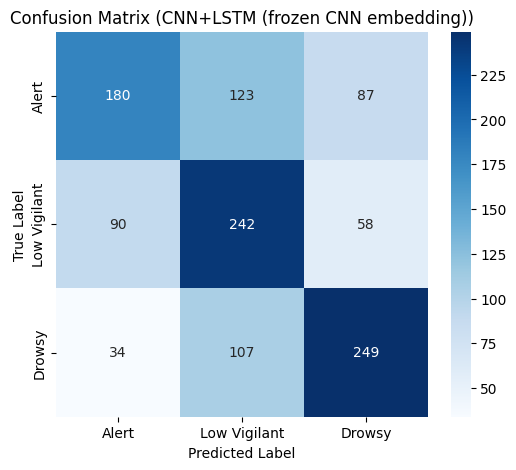


Accuracy by window duration (CNN+LSTM (frozen CNN embedding)):
                     accuracy  n_windows
window_duration_sec                     
3.0                  0.572222        540
5.0                  0.580556        360
10.0                 0.566667        180
20.0                 0.566667         90


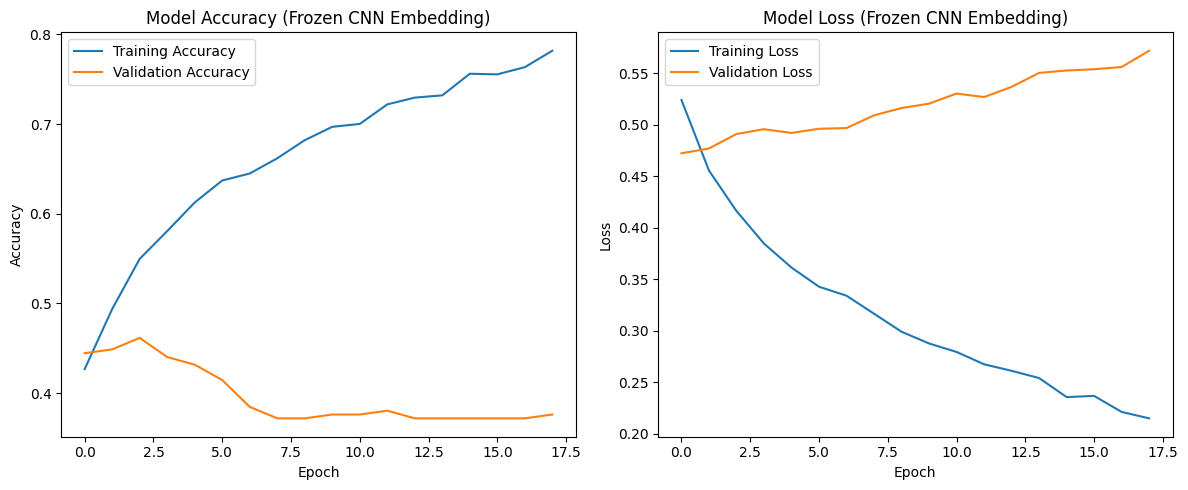

In [19]:
y_true_frozen, y_pred_frozen, per_duration_frozen = evaluate_variant(
    os.path.join(models_folder, 'best_cnn_lstm_frozen_embedding.keras'),
    model_frozen_embedding, test_ds_frozen, df_test, 'CNN+LSTM (frozen CNN embedding)',
)

if 'history_frozen_embedding' in globals():
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_frozen_embedding.history['accuracy'], label='Training Accuracy')
    plt.plot(history_frozen_embedding.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy (Frozen CNN Embedding)'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history_frozen_embedding.history['loss'], label='Training Loss')
    plt.plot(history_frozen_embedding.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss (Frozen CNN Embedding)'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
    plt.tight_layout()
    plt.show()

## MobileNetV2 Transfer-Learning Variant (Frozen Backbone → Fine-Tune) — **DISABLED**

**The code cell below is commented out, not deleted or re-run.** All numbers in this section are
from pre-migration 3-class runs; MobileNetV2 stays disabled regardless of the binary switch.
Across every real run of this notebook so far, MobileNetV2 has consistently overfit far harder
than the from-scratch backbone, not just underperformed it:

- The most recent run (frozen head, `AdamW`/`recurrent_dropout` era) reached **95%+ train
  accuracy by epoch 6** while `val_macro_f1` never climbed above **0.36**, mostly sitting in the
  0.24-0.33 range and trending worse, not better, as training continued — a far more extreme
  train/val gap than the from-scratch backbone showed in the same run (peak `val_macro_f1` 0.42,
  test macro-F1 0.3296). The run was stopped before the fine-tune/comparison cells below it ran,
  since the frozen-head log alone was already conclusive enough not to justify the extra compute.
- This is consistent with — and worse than — every prior MobileNetV2 result in this project:
  07's single-frame MobileNetV2 collapsed to 16.81% accuracy with zero recall on one class, and
  this notebook's own earlier (pre-fusion, 54-subject) run put MobileNetV2 (frozen) at only
  33.68% test accuracy — never once ahead of the from-scratch backbone on a trustworthy run.

Same two-phase recipe as 07 when it *was* enabled: train the new head
(`TimeDistributed(MobileNetV2) → LSTM → Dense`) to convergence with the pretrained backbone
completely frozen first, then unfreeze a small number of the backbone's final layers and continue
at a much lower learning rate. Uses `train_ds_mobilenet`/`val_ds_mobilenet`/`test_ds_mobilenet`
(the `IMG_SIZE_MOBILENET=128` pipeline, not the from-scratch model's 96×96 one) and the same
`weight_dict`/val-macro-F1-based callback pattern as the from-scratch model above, so any
accuracy/recall difference between the two backbones was attributable to architecture and
resolution, not to a different training setup — worth keeping in mind if this is ever re-enabled
to test a genuinely different MobileNetV2 configuration, rather than assumed dead permanently.


In [ ]:
# --- DISABLED: commented out, not deleted -- outputs below are kept as the historical
# record of the last real run. See the markdown cell above for why. To re-enable, remove
# the leading '# ' from every line below. ---
# mobilenet_extractor, mobilenet_base = build_mobilenet_feature_extractor(
#     IMG_SIZE_MOBILENET, alpha=1.0, trainable_backbone=False,
# )
# model_mobilenet = build_cnn_lstm(mobilenet_extractor, img_size=IMG_SIZE_MOBILENET,
#                                   name='cnn_lstm_mobilenet')
# model_mobilenet.summary()

# macro_f1_cb_mn = MacroF1Callback(val_ds_mobilenet)
# early_stopping_mn = EarlyStopping(monitor='val_macro_f1', mode='max', patience=15,
#                                    restore_best_weights=True)
# checkpoint_mn_frozen = ModelCheckpoint(
#     filepath=os.path.join(models_folder, 'best_cnn_lstm_mobilenet_frozen.keras'),
#     monitor='val_macro_f1', mode='max', save_best_only=True,
# )
# # patience tightened from 8 -> 4, same reasoning as the from-scratch backbone's reduce_lr above.
# reduce_lr_mn = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

# print("🚀 Training CNN+LSTM (MobileNetV2 backbone, frozen)...")
# history_mobilenet_frozen = model_mobilenet.fit(
#     train_ds_mobilenet,
#     epochs=100,
#     validation_data=val_ds_mobilenet,
#     callbacks=[macro_f1_cb_mn, early_stopping_mn, checkpoint_mn_frozen, reduce_lr_mn],
#     class_weight=weight_dict,
#     verbose=1,
# )


### Fine-Tuning Phase — **DISABLED** (see the section markdown above)

Unfreeze the last ~30 layers of the MobileNetV2 base and continue at a much lower learning rate
(`1e-5`), same reasoning as 07. One real difference from 07 here: the MobileNetV2 base is nested
*inside* the `TimeDistributed`-wrapped feature extractor sub-model, not a direct top-level
sub-model of a flat functional model like 07's — 07's
`next(l for l in model.layers if isinstance(l, tf.keras.Model))` wouldn't find it here, so
`_find_mobilenet_base` below walks into the `TimeDistributed` layer's wrapped `.layer` first.
This phase never actually ran in the most recent pass — the frozen-head log alone already showed
severe overfitting, so fine-tuning an already-overfit head wasn't worth the additional compute.


In [ ]:
# --- DISABLED: commented out, not deleted -- outputs below are kept as the historical
# record of the last real run. See the markdown cell above for why. To re-enable, remove
# the leading '# ' from every line below. ---
# best_frozen_path = os.path.join(models_folder, 'best_cnn_lstm_mobilenet_frozen.keras')
# custom_objects = {'SparseCategoricalFocalLoss': SparseCategoricalFocalLoss}

# print(f"Loading best frozen-head checkpoint from {best_frozen_path}...")
# # Load with compile=False to allow manual modification of layer attributes before re-compiling
# model_mobilenet_ft = tf.keras.models.load_model(best_frozen_path, custom_objects=custom_objects, compile=False)

# # Fix for cuDNN error: Ensure LSTM layers use_cudnn=False for pre-padded sequences
# for layer in model_mobilenet_ft.layers:
#     if isinstance(layer, tf.keras.layers.LSTM):
#         layer.use_cudnn = False

# def _find_mobilenet_base(model):
#     """Walks into the TimeDistributed-wrapped feature extractor to find the nested MobileNetV2
#     base -- see the markdown cell above for why this differs from 07's flat top-level lookup.
#     """
#     for layer in model.layers:
#         if isinstance(layer, TimeDistributed):
#             inner = layer.layer
#             for sub in inner.layers:
#                 if isinstance(sub, tf.keras.Model) and 'mobilenetv2' in sub.name.lower():
#                     return sub
#     raise ValueError("Could not locate the MobileNetV2 base layer inside the loaded model.")


# base_ft = _find_mobilenet_base(model_mobilenet_ft)
# base_ft.trainable = True
# FINE_TUNE_UNFREEZE_LAYERS = 30
# for layer in base_ft.layers[:-FINE_TUNE_UNFREEZE_LAYERS]:
#     layer.trainable = False
# for layer in base_ft.layers[-FINE_TUNE_UNFREEZE_LAYERS:]:
#     if isinstance(layer, BatchNormalization):
#         # Keep BatchNorm's running statistics frozen even among the "unfrozen" layers -- letting
#         # it keep computing batch statistics from this project's small batches would destabilize
#         # training, independent of which layers are otherwise trainable. Same reasoning as 07.
#         layer.trainable = False

# from tensorflow.keras.optimizers import AdamW

# FINE_TUNE_LR = 1e-5
# # Re-compile is required after loading with compile=False and modifying layer trainability.
# # AdamW (matching build_cnn_lstm's frozen-phase optimizer above), not plain Adam -- see cell 12's
# # "Regularization update" note for why. WEIGHT_DECAY reused from cell 12; FINE_TUNE_LR itself is
# # untouched -- the overfitting diagnosis (see build_cnn_lstm's docstring) was about the frozen
# # phase's learning_rate, not this already-separate, already-much-lower fine-tune LR.
# model_mobilenet_ft.compile(optimizer=AdamW(learning_rate=FINE_TUNE_LR, weight_decay=WEIGHT_DECAY),
#                             loss=build_loss(), metrics=['accuracy'])

# macro_f1_cb_ft = MacroF1Callback(val_ds_mobilenet)
# early_stopping_ft = EarlyStopping(monitor='val_macro_f1', mode='max', patience=8,
#                                    restore_best_weights=True)
# checkpoint_ft = ModelCheckpoint(
#     filepath=os.path.join(models_folder, 'best_cnn_lstm_mobilenet_finetuned.keras'),
#     monitor='val_macro_f1', mode='max', save_best_only=True,
# )
# reduce_lr_ft = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-8, verbose=1)

# print(f"🚀 Fine-tuning MobileNetV2 (last {FINE_TUNE_UNFREEZE_LAYERS} backbone layers, "
#       f"lr={FINE_TUNE_LR})...")
# history_mobilenet_ft = model_mobilenet_ft.fit(
#     train_ds_mobilenet,
#     epochs=20,
#     validation_data=val_ds_mobilenet,
#     callbacks=[macro_f1_cb_ft, early_stopping_ft, checkpoint_ft, reduce_lr_ft],
#     class_weight=weight_dict,
#     verbose=1,
# )

# model_mobilenet_ft.save(cnn_lstm_mobilenet_model_path)
# print(f"💾 Model saved: {cnn_lstm_mobilenet_model_path}")


## MobileNetV2 Evaluation + Scratch vs. MobileNetV2 Comparison — **DISABLED**

Same `evaluate_variant` helper as the from-scratch model above, run against the fine-tuned
checkpoint (and the frozen-only checkpoint, for a full three-way comparison) when this section is
enabled. The comparison table combines both backbones' overall numbers **and** their per-duration
breakdowns, so it answers two questions at once: which backbone generalizes better to held-out
subjects, and whether either one actually benefits from more temporal context. Didn't run in the
most recent pass since cells 18/20 above are commented out — no frozen/fine-tuned checkpoints
exist to evaluate.


In [ ]:
# --- DISABLED: commented out, not deleted -- outputs below are kept as the historical
# record of the last real run. See the markdown cell above for why. To re-enable, remove
# the leading '# ' from every line below. ---
# y_true_mn_frozen, y_pred_mn_frozen, per_duration_mn_frozen = evaluate_variant(
#     os.path.join(models_folder, 'best_cnn_lstm_mobilenet_frozen.keras'),
#     model_mobilenet, test_ds_mobilenet, df_test, 'CNN+LSTM (MobileNetV2, frozen)',
# )

# y_true_mn_ft, y_pred_mn_ft, per_duration_mn_ft = evaluate_variant(
#     os.path.join(models_folder, 'best_cnn_lstm_mobilenet_finetuned.keras'),
#     model_mobilenet_ft, test_ds_mobilenet, df_test, 'CNN+LSTM (MobileNetV2, fine-tuned)',
# )

# # --- Overall comparison table: scratch vs. MobileNetV2 frozen vs. fine-tuned ---
# comparison_rows = []
# for variant_name, y_pred_variant in [
#     ('CNN+LSTM (from-scratch)', y_pred_scratch),
#     ('CNN+LSTM (MobileNetV2, frozen)', y_pred_mn_frozen),
#     ('CNN+LSTM (MobileNetV2, fine-tuned)', y_pred_mn_ft),
# ]:
#     report = classification_report(y_true_scratch, y_pred_variant, target_names=CLASS_NAMES,
#                                     output_dict=True, zero_division=0)
#     comparison_rows.append({
#         'Variant': variant_name,
#         'Test Accuracy': report['accuracy'],
#         'Macro F1': report['macro avg']['f1-score'],
#         'Not Drowsy Recall': report['Not Drowsy']['recall'],
#         'Drowsy Recall': report['Drowsy']['recall'],
#     })
# comparison_df = pd.DataFrame(comparison_rows).set_index('Variant')
# print("\n=== Scratch vs. MobileNetV2 (frozen) vs. MobileNetV2 (fine-tuned) ===")
# print(comparison_df.round(4))

# # --- Per-duration comparison table -- does more temporal context actually help, per backbone? ---
# per_duration_comparison = pd.concat(
#     {
#         'from-scratch': per_duration_scratch['accuracy'],
#         'mobilenet_frozen': per_duration_mn_frozen['accuracy'],
#         'mobilenet_finetuned': per_duration_mn_ft['accuracy'],
#     },
#     axis=1,
# )
# print("\n=== Accuracy by window duration, per backbone ===")
# print(per_duration_comparison.round(4))


## Reading This Result Alongside the Other Models

**Current status: MobileNetV2 is disabled (see above); from-scratch is the backbone this notebook
is actually pursuing going forward.** Across every real run so far, MobileNetV2 has overfit more
severely than the from-scratch backbone, not just scored lower — most recently 95%+ train
accuracy against a `val_macro_f1` ceiling around 0.36 (vs. from-scratch's 0.42 peak, 0.3296 test
macro-F1 in the same run). This isn't one bad run: 07's single-frame MobileNetV2 collapsed
similarly (16.81% accuracy, zero recall on one class), and this notebook's own earlier
pre-fusion run also had MobileNetV2 underperforming from-scratch on the full subject pool. The
`alpha=1.0`/`IMG_SIZE_MOBILENET=128` fix (vs. 07's `alpha=0.35`/96×96) was a real, reasoned
attempt at the resolution/alpha mismatch diagnosed in `notebook/CLAUDE.md`'s "Cheaper options" —
it wasn't the answer; frozen ImageNet features plus a from-scratch conv stack trained specifically
for this task's small, tightly-cropped face images just doesn't transfer as well here as training
that stack from scratch does.

**Pre-migration 3-class record (no binary run yet).** The from-scratch backbone's last 3-class
run (`AdamW` + `recurrent_dropout` + `class_weight=None`) measured 35.04% test accuracy, 0.3296
macro-F1 — a real improvement over the same backbone's prior run without those changes (29.83% /
0.2801), and close to but never clearly beating 07's single-frame CNN (36.67% / 0.3614). That
last comparison is the one that still matters after the binary switch: the temporal-context
premise was never validated against the single-frame CNN in 3-class, and collapsing to two
classes doesn't answer it either. `val_macro_f1` still peaked early (epoch 5, 0.4182) and declined afterward as
`ReduceLROnPlateau` cut the learning rate down through the rest of the run — direct, within-run
evidence that a *lower* learning rate didn't help here either (val_macro_f1 at the lowest LR,
6.25e-06, was ~0.22-0.23, worse than at every higher LR tried earlier in the same run), on top of
the cross-run evidence already gathered against that lever.

- `07_cnn_training.ipynb`'s single-frame CNN (36.67% accuracy, 0.3614 macro-F1, from-scratch;
  16.81% accuracy, MobileNetV2) — this run's from-scratch CNN+LSTM (35.04%/0.3296) is now close
  to but still hasn't clearly beaten 07's single-frame result, so the temporal-context premise
  still isn't validated, even with the fusion/regularization changes.
- The per-duration breakdown (see the from-scratch eval cell above) is the direct test of whether
  more temporal context is paying for itself at all — check that before assuming duration is
  helping.

**Not built here, worth doing next depending on what further runs show:**
- A subject-fold cross-validation diagnostic (mirroring 07's `RUN_CROSS_VALIDATION`) — see the
  "Splitting the Dataset" markdown cell's note on the small, fixed 234-window validation pool
  being a plausible independent source of `val_macro_f1` noise, on top of the LR/overfitting
  question above.
- A learning-rate *schedule* change (e.g. cosine decay with warm restarts) instead of
  `ReduceLROnPlateau`'s monotonic decay — under discussion, not yet decided or implemented.
- If MobileNetV2 is ever revisited, see `notebook/CLAUDE.md`'s "Cheaper options considered
  alongside the full CNN+LSTM build" for lower-data-cost fallbacks already discussed (a
  late-fusion ensemble of RandomForest/Dense NN/CNN, or feeding 07's frozen CNN embedding into
  the existing geometric LSTM instead of training a CNN from scratch inside the recurrent loop).
